# Introduction - Exploratory Analysis

In this notebook, we will conduct an analysis of the data previously prepared in the path: `data/interim/hockey_teams.json`. This file, being partially processed, is easily accessible for import and ready for more detailed analytical examination.

This part of the workshop will focus on utilizing `pandas` and `matplotlib`, which were discussed during the course. The main objective is to familiarize ourselves with the dataset we are working on. Through a series of exercises:  
- we will get to know the structure of the data,  
- we will conduct elementary data exploration (EDA).

## Column Description

Below is a brief description of each column in our dataset:

- **Team Name**: The name of the team participating in the match.
- **Year**: The year in which the season takes place.
- **Wins**: The number of matches won by the team in the given season.
- **Losses**: The number of matches lost by the team in the given season.
- **OT Losses**: The number of matches lost by the team in overtime in the given season.
- **Win %**: The percentage of matches won by the team in the given season.
- **Goals For (GF)**: The number of goals scored by the team in the given season.
- **Goals Against (GA)**: The number of goals conceded by the team in the given season.
- **+ / -**: The difference between the number of goals scored and conceded by the team in the given season.

> Note: At this stage, certain significant simplifications were intentionally made in the analysis and they will not be explicitly mentioned, aiming for a discussion at the end of the workshop.

# Preparation

## Import libraries
Here, load the libraries that will be needed in the following steps

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import json
os.chdir(r"/workspaces/CLab_workshop")
print(os.getcwd())

/workspaces/CLab_workshop


# Loading the Dataset

We recommend loading the raw data into a variable with the suffix `_raw`. This will avoid the need to reload the data from the beginning in case of an error, which can be a time-consuming process.  
  
> **Tip:** A `json` file can be easily loaded using `pandas` with the `read_json` function - [click](https://pandas.pydata.org/docs/reference/api/pandas.read_json.html)  

Load data from the `hockey_teams` file here

In [8]:
# this doesn't realy work (it makes all just one column):
# df = pd.read_json(r"data\interim\hockey_teams.json")

with open("data/interim/hockey_teams.json", "r", encoding="utf-8") as file:
    data = json.loads(file.read())

df_raw = pd.DataFrame(data["team cards"])


Check here if the data loaded correctly

In [9]:
print(df_raw)
print(df_raw.info())

                   Team Name  Year Wins Losses OT Losses  Win %  \
0              Boston Bruins  1990   44     24             0.55   
1             Buffalo Sabres  1990   31     30            0.388   
2             Calgary Flames  1990   46     26            0.575   
3         Chicago Blackhawks  1990   49     23            0.613   
4          Detroit Red Wings  1990   34     38            0.425   
..                       ...   ...  ...    ...       ...    ...   
602        Vancouver Canucks  1997   25     43            0.305   
603      Washington Capitals  1997   40     30            0.488   
604  Mighty Ducks of Anaheim  1998   35     34            0.427   
605            Boston Bruins  1998   39     30            0.476   
606           Buffalo Sabres  1998   37     28            0.451   

    Goals For (Gf) Goals Against (GA) + /-  
0              299                264   35  
1              292                278   14  
2              344                263   81  
3              

# Preliminary Data Transformation

## Standardizing Column Names

Currently, our dataset contains original column names which, from a technical standpoint, should not contain spaces or other special characters.

In this section, we will standardize and simplify the naming conventions to facilitate data processing in subsequent stages. We will apply the following column name mapping:

- **Team Name** -> `team`
- **Year** -> `season`
- **Wins** -> `victories`
- **Losses** -> `defeats`
- **OT Losses** -> `overtime_defeats`
- **Win %** -> `victory_percentage`
- **Goals For (GF)** -> `scored_goals`
- **Goals Against (GA)** -> `received_goals`
- **\+ / -** -> `goal_difference`

> At this point, we recommend creating a new DataFrame without the `_raw` postfix. For example, if the data was loaded into the variable `df_raw`, we now want to work with the variable `df`, where we will modify the column names.

In [10]:

df = df_raw.rename(columns = {
    "Team Name":"team",
    "Year": "season",
    "Wins":"victories",
    "Losses": "defeats",
    "OT Losses": "overtime_defeats",
    "Win %": "victory_percentage",
    "Goals For (Gf)": "scored_goals",
    "Goals Against (GA)" : "received_goals",
    "+ /-": "goal_difference"
})

df

,team,season,victories,defeats,overtime_defeats,victory_percentage,scored_goals,received_goals,goal_difference
0,Boston Bruins,1990,44,24,,0.55,299,264,35
1,Buffalo Sabres,1990,31,30,,0.388,292,278,14
2,Calgary Flames,1990,46,26,,0.575,344,263,81
3,Chicago Blackhawks,1990,49,23,,0.613,284,211,73
4,Detroit Red Wings,1990,34,38,,0.425,273,298,-25
...,...,...,...,...,...,...,...,...,...
602,Vancouver Canucks,1997,25,43,,0.305,224,273,-49
603,Washington Capitals,1997,40,30,,0.488,219,202,17
604,Mighty Ducks of Anaheim,1998,35,34,,0.427,215,206,9
605,Boston Bruins,1998,39,30,,0.476,214,181,33


## Removing Empty Values

As can be observed, the `overtime_defeats` column contains many empty values, and the expected data type is `int`. Before proceeding with further analysis, this column needs to be properly prepared.

To achieve this, we will perform the following steps:
- Check which symbol is used as an indicator of an empty field.
- Fill the empty fields with a value of 0.
- Then convert the data type of this column to `int`.

By following these steps, the `overtime_defeats` column will be ready for further analysis.

### Finding the Indicator of an Empty Field

In [11]:
ot_defeats = df["overtime_defeats"]
#print(ot_defeats)
print(type(ot_defeats[0]))
print(ot_defeats[0]== "1") # False (this is just a test whether this method works)
print(ot_defeats[0]== " ") # False
print(ot_defeats[0]== "") # True
# ok, so null values are represented by empty strings

<class 'str'>
False
False
True


### Overwriting Empty Values with 0

In [12]:
df.loc[df["overtime_defeats"]== "","overtime_defeats"] = "0"
# checking whether I didnt accidentaly overwrite non-empty values:
rangers = df.query("team == 'New York Rangers'") 
print(rangers)
# result:
df

                 team season victories defeats overtime_defeats  \
12   New York Rangers   1990        36      31                0   
38   New York Rangers   1998        33      38                0   
66   New York Rangers   1999        29      38                3   
96   New York Rangers   2000        33      43                1   
126  New York Rangers   2001        36      38                4   
156  New York Rangers   2002        32      36                4   
186  New York Rangers   2003        27      40                8   
216  New York Rangers   2005        44      26               12   
246  New York Rangers   2006        42      30               10   
287  New York Rangers   1990        36      31                0   
301  New York Rangers   2007        42      27               13   
331  New York Rangers   2008        43      30                9   
361  New York Rangers   2009        38      33               11   
391  New York Rangers   2010        44      33                

,team,season,victories,defeats,overtime_defeats,victory_percentage,scored_goals,received_goals,goal_difference
0,Boston Bruins,1990,44,24,0,0.55,299,264,35
1,Buffalo Sabres,1990,31,30,0,0.388,292,278,14
2,Calgary Flames,1990,46,26,0,0.575,344,263,81
3,Chicago Blackhawks,1990,49,23,0,0.613,284,211,73
4,Detroit Red Wings,1990,34,38,0,0.425,273,298,-25
...,...,...,...,...,...,...,...,...,...
602,Vancouver Canucks,1997,25,43,0,0.305,224,273,-49
603,Washington Capitals,1997,40,30,0,0.488,219,202,17
604,Mighty Ducks of Anaheim,1998,35,34,0,0.427,215,206,9
605,Boston Bruins,1998,39,30,0,0.476,214,181,33


### Column Type Conversion

In [13]:
df["overtime_defeats"] = pd.to_numeric(df["overtime_defeats"], errors="coerce")
print(type(df["overtime_defeats"][0]))

<class 'numpy.int64'>


# Dataset Analysis

In this section, we will focus on answering fundamental questions about our dataset in the context of hockey games. The goal is to become familiar with the dataset and develop an intuition about it.  
  
Here is a list of exercises we will perform to find answers to key questions:  
  
- How many teams have participated in league games over the years?  
- What is the total number of available seasons?  
- What is the time span of the data?  
- Are there any suspicious or outlier values in the numerical columns?  
  
These exercises will help us better understand the structure and nature of our data.  

### Number of teams that participated in league matches

Here, indicate the total number of teams available in our dataset

In [14]:
unique_teams = df["team"].unique()
print(unique_teams)
print(len(unique_teams)) # 35 teams

<StringArray>
[          'Boston Bruins',          'Buffalo Sabres',
          'Calgary Flames',      'Chicago Blackhawks',
       'Detroit Red Wings',         'Edmonton Oilers',
        'Hartford Whalers',       'Los Angeles Kings',
   'Minnesota North Stars',      'Montreal Canadiens',
       'New Jersey Devils',      'New York Islanders',
        'New York Rangers',     'Philadelphia Flyers',
     'Pittsburgh Penguins',        'Quebec Nordiques',
         'St. Louis Blues',     'Toronto Maple Leafs',
       'Vancouver Canucks',     'Washington Capitals',
           'Winnipeg Jets',     'Carolina Hurricanes',
      'Colorado Avalanche',            'Dallas Stars',
        'Florida Panthers',     'Nashville Predators',
         'Ottawa Senators',         'Phoenix Coyotes',
         'San Jose Sharks',     'Tampa Bay Lightning',
 'Mighty Ducks of Anaheim',       'Atlanta Thrashers',
   'Columbus Blue Jackets',          'Minnesota Wild',
           'Anaheim Ducks']
Length: 35, dtype: str


### Total number of seasons

Here, indicate the total number of seasons.

In [15]:
seasons = df["season"].unique()
print(seasons)
print(len(seasons)) # 21 seasons

<StringArray>
['1990', '1991', '1998', '1999', '2000', '2001', '2002', '2003', '2005',
 '2006', '2007', '2008', '2009', '2010', '2011', '1992', '1993', '1994',
 '1995', '1996', '1997']
Length: 21, dtype: str
21


### Time Span of Data

Here, we will examine the availability of data for individual seasons. The analysis will be conducted in two stages:  
- First, we will determine the time range of the data by identifying the start year (`start_year`) and the end year (`end_year`). This will allow us to establish for which seasons we have information.  
- Next, we will look for any gaps in the time data to ensure that we have a complete set of information for each season.   

At this point, we will determine the start year and end year of the data:

In [16]:
seasons_int = []
for season in seasons:
    season_int = int(season)
    seasons_int.append(season_int)

seasons_int.sort()
print(seasons_int) # its 1990 to 2011

[1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2005, 2006, 2007, 2008, 2009, 2010, 2011]


Here, we will check if data is present for each year within the determined range:

In [ ]:
# obviously 2004 is missing, see printed statement from previous cell

### Analysis of Numerical Columns

Here we will examine the basic descriptive statistics for numerical columns.

To this end, describe and analyze the results for the following columns:

- victories
- defeats
- overtime_defeats
- victory_percentage
- scored_goals
- received_goals
- goal_difference

We are interested in the following statistics:
- mean,
- count,
- standard deviation,
- percentiles = `[0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1]`

In [17]:
print(type(df["victories"][0])) # string
df["victories"] = pd.to_numeric(df["victories"], errors="coerce")
df["defeats"] = pd.to_numeric(df["defeats"], errors="coerce")
df["victory_percentage"] = pd.to_numeric(df["victory_percentage"], errors="coerce")
df["scored_goals"] = pd.to_numeric(df["scored_goals"], errors="coerce")
df["received_goals"] = pd.to_numeric(df["received_goals"], errors="coerce")
df["goal_difference"] = pd.to_numeric(df["goal_difference"], errors="coerce")

print("victories:\n", df["victories"].describe(percentiles=[
    0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1
]).loc[["count", "mean", "std", "0%", "5%", "10%", "25%", "50%", "75%", "90%", "95%", "100%"]])

print("\n")

print("defeats:\n", df["defeats"].describe(percentiles=[
    0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1
]).loc[["count", "mean", "std", "0%", "5%", "10%", "25%", "50%", "75%", "90%", "95%", "100%"]])

print("\n")

print("overtime_defeats:\n", df["overtime_defeats"].describe(percentiles=[
    0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1
]).loc[["count", "mean", "std", "0%", "5%", "10%", "25%", "50%", "75%", "90%", "95%", "100%"]])

print("\n")

print("victory_percentage:\n", df["victory_percentage"].describe(percentiles=[
    0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1
]).loc[["count", "mean", "std", "0%", "5%", "10%", "25%", "50%", "75%", "90%", "95%", "100%"]])

print("\n")

print("scored_goals:\n", df["scored_goals"].describe(percentiles=[
    0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1
]).loc[["count", "mean", "std", "0%", "5%", "10%", "25%", "50%", "75%", "90%", "95%", "100%"]])

print("\n")

print("received_goals:\n", df["received_goals"].describe(percentiles=[
    0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1
]).loc[["count", "mean", "std", "0%", "5%", "10%", "25%", "50%", "75%", "90%", "95%", "100%"]])

print("\n")

print("goal_difference:\n", df["goal_difference"].describe(percentiles=[
    0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1
]).loc[["count", "mean", "std", "0%", "5%", "10%", "25%", "50%", "75%", "90%", "95%", "100%"]])


<class 'str'>
victories:
 count    607.000000
mean      36.841845
std        8.902925
0%         9.000000
5%        21.300000
10%       24.600000
25%       31.000000
50%       38.000000
75%       43.000000
90%       48.000000
95%       50.000000
100%      62.000000
Name: victories, dtype: float64


defeats:
 count    607.000000
mean      32.443163
std        8.383721
0%        11.000000
5%        20.000000
10%       23.000000
25%       27.000000
50%       32.000000
75%       37.000000
90%       43.000000
95%       47.000000
100%      71.000000
Name: defeats, dtype: float64


overtime_defeats:
 count    607.000000
mean       4.400329
std        4.600854
0%         0.000000
5%         0.000000
10%        0.000000
25%        0.000000
50%        4.000000
75%        8.000000
90%       11.000000
95%       13.000000
100%      18.000000
Name: overtime_defeats, dtype: float64


victory_percentage:
 count    607.000000
mean       0.457389
std        0.102289
0%         0.119000
5%         0.2818

# `team`

In this section, we will conduct a series of analyses on individual teams participating in the leagues. This will allow us to identify the teams that have performed best in the competitions over the years.


## Analysis of Team Participation in League Seasons
Let's perform the following exercises:

- Check how many teams have participated in all seasons of the selected league.
- Display the list of these teams.

In [18]:
df_by_season = df.groupby("season")
for (key, season_statistics) in df_by_season:
    print(key)
    print(season_statistics) # yea, it works

1990
                      team season  victories  defeats  overtime_defeats  \
0            Boston Bruins   1990         44       24                 0   
1           Buffalo Sabres   1990         31       30                 0   
2           Calgary Flames   1990         46       26                 0   
3       Chicago Blackhawks   1990         49       23                 0   
4        Detroit Red Wings   1990         34       38                 0   
5          Edmonton Oilers   1990         37       37                 0   
6         Hartford Whalers   1990         31       38                 0   
7        Los Angeles Kings   1990         46       24                 0   
8    Minnesota North Stars   1990         27       39                 0   
9       Montreal Canadiens   1990         39       30                 0   
10       New Jersey Devils   1990         32       33                 0   
11      New York Islanders   1990         25       45                 0   
12        New York R

List of teams that participated in all seasons of hockey competitions:

In [19]:
type(unique_teams)

teams_as_list = list(unique_teams)
print(len(teams_as_list))
print(teams_as_list)


for (key, season_statistics) in df_by_season:
    teams_in_season = list(season_statistics["team"])
    for team in teams_as_list:
        if team not in teams_in_season:
            teams_as_list.remove(team)
print(len(teams_as_list))

for team in teams_as_list: # making it a nice column
    print(team)



35
['Boston Bruins', 'Buffalo Sabres', 'Calgary Flames', 'Chicago Blackhawks', 'Detroit Red Wings', 'Edmonton Oilers', 'Hartford Whalers', 'Los Angeles Kings', 'Minnesota North Stars', 'Montreal Canadiens', 'New Jersey Devils', 'New York Islanders', 'New York Rangers', 'Philadelphia Flyers', 'Pittsburgh Penguins', 'Quebec Nordiques', 'St. Louis Blues', 'Toronto Maple Leafs', 'Vancouver Canucks', 'Washington Capitals', 'Winnipeg Jets', 'Carolina Hurricanes', 'Colorado Avalanche', 'Dallas Stars', 'Florida Panthers', 'Nashville Predators', 'Ottawa Senators', 'Phoenix Coyotes', 'San Jose Sharks', 'Tampa Bay Lightning', 'Mighty Ducks of Anaheim', 'Atlanta Thrashers', 'Columbus Blue Jackets', 'Minnesota Wild', 'Anaheim Ducks']
18
Boston Bruins
Buffalo Sabres
Calgary Flames
Chicago Blackhawks
Detroit Red Wings
Edmonton Oilers
Los Angeles Kings
Montreal Canadiens
New Jersey Devils
New York Islanders
New York Rangers
Philadelphia Flyers
Pittsburgh Penguins
St. Louis Blues
Toronto Maple Leafs
Va

The number of teams that have played in all seasons:

In [20]:
print(len(teams_as_list))

18


## Best Performing Teams in League History

Let's list the five best teams with the highest average `victory_percentage` over all years, presenting the data broken down by individual teams and seasons.

In [21]:
for (year,data) in df_by_season:
    sort_by_victory_share = data.sort_values(by="victory_percentage", ascending=False)
    # When I first tried this, I found out some duplicates, so:
    sort_by_victory_share = sort_by_victory_share.drop_duplicates() 
    print("\n")
    print(year)
    print(sort_by_victory_share[["team","victory_percentage"]].head())



1990
                   team  victory_percentage
3    Chicago Blackhawks               0.613
16      St. Louis Blues               0.588
7     Los Angeles Kings               0.575
277      Calgary Flames               0.575
275       Boston Bruins               0.550


1991
                    team  victory_percentage
440     New York Rangers               0.625
448  Washington Capitals               0.562
432    Detroit Red Wings               0.537
447    Vancouver Canucks               0.525
437   Montreal Canadiens               0.512


1992
                    team  victory_percentage
465  Pittsburgh Penguins               0.667
450        Boston Bruins               0.607
459   Montreal Canadiens               0.571
453   Chicago Blackhawks               0.560
454    Detroit Red Wings               0.560


1993
                    team  victory_percentage
488     New York Rangers               0.619
486    New Jersey Devils               0.560
480    Detroit Red Wings         

## Top Teams in History

Let's determine the top 5 teams that have won the most league titles in entire history. Let's consider whether, based on the available data, we can identify a single team that unquestionably deserves the title of the best in history.

For simplicity, let's assume that the league winner is the team with the most victories in a given season.

> Hint: The information contained in the article `Pandas > Summary of the 4th Meeting > Analytical Functions` may be useful.

In [22]:

winners = []

for (year,data) in df_by_season:
    sort_by_victories = data.sort_values(by="victories", ascending=False)
    season_winner = sort_by_victories[["season","team","victories"]].head(1)
    print(season_winner)
    # here AI advised me to reset index (it did not work otherwise):
    teams_sorted = sort_by_victories["team"].reset_index(drop=True)
    winners.append(teams_sorted[0])
    
print("\n")
winners_countable = pd.Series(winners)
print(f"And the winner is {winners_countable.mode()}") # Detroit Red Wings


  season                team  victories
3   1990  Chicago Blackhawks         49
    season              team  victories
440   1991  New York Rangers         50
    season                 team  victories
465   1992  Pittsburgh Penguins         56
    season              team  victories
488   1993  New York Rangers         52
    season               team  victories
506   1994  Detroit Red Wings         33
    season               team  victories
533   1995  Detroit Red Wings         62
    season                team  victories
557   1996  Colorado Avalanche         49
    season          team  victories
585   1997  Dallas Stars         49
   season          team  victories
29   1998  Dallas Stars         51
   season             team  victories
72   1999  St. Louis Blues         51
   season                team  victories
85   2000  Colorado Avalanche         52
    season               team  victories
117   2001  Detroit Red Wings         51
    season             team  victories
157  

Additionally, we will determine how many teams have **never won any season**.  
  
> **Note:** This task may seem more complex than it appears at first glance. Remember, during classes you can rely on the instructor's help, and outside of them - on the support of a mentor.

In [23]:
print(winners_countable.unique())
no_of_teams_never_winning_a_season = len(unique_teams) - len(winners_countable.unique())
print(no_of_teams_never_winning_a_season) # 23

<StringArray>
[ 'Chicago Blackhawks',    'New York Rangers', 'Pittsburgh Penguins',
   'Detroit Red Wings',  'Colorado Avalanche',        'Dallas Stars',
     'St. Louis Blues',     'Ottawa Senators',      'Buffalo Sabres',
       'Boston Bruins', 'Washington Capitals',   'Vancouver Canucks']
Length: 12, dtype: str
23


# `overtime_defeats`

The `overtime_defeats` variable informs us how many times a team lost in overtime throughout the year.  
  
In this section, we will perform the following exercises:  
- Identify the team that most frequently lost in overtime.  
- Rank the teams based on the number of overtime losses.  
- Calculate what percentage of teams lost at least once in overtime.  
- Determine the season with the highest number of games decided in overtime.  
  
> Let's make sure that the `overtime_defeats` column is of numeric type!  

## The team losing most frequently in overtime

> Note: To solve this task, this article might be useful: `Pandas > Conference Summary > Analytical Functions`

In [24]:
"""warning: this cell only returns sensible results if 
previous cells were executed in order.
"""
rows = []

df = df.drop_duplicates() #just to be sure

df_by_team = df.groupby("team")
for (team, team_statistics) in df_by_team:
    # print(team)
    sum_of_overtime_defeats = team_statistics["overtime_defeats"].sum()
    #print(team_statistics[["team", "overtime_defeats"]]) # for control
    rows.append({"team": team, "overtime_defeats": sum_of_overtime_defeats})

teams_by_overtime_defeats = pd.DataFrame(rows)
teams_by_overtime_defeats_sorted = teams_by_overtime_defeats.sort_values(by="overtime_defeats", ascending=False)
teams_by_overtime_defeats_sorted # Florida Panthers are"first", with 124 overtime defeats


,team,overtime_defeats
12,Florida Panthers,124
2,Boston Bruins,106
29,St. Louis Blues,101
31,Toronto Maple Leafs,96
18,Montreal Canadiens,96
30,Tampa Bay Lightning,96
28,San Jose Sharks,94
4,Calgary Flames,94
11,Edmonton Oilers,94
14,Los Angeles Kings,93


## Percentage of teams losing in overtime

The result of this task should be rounded to two decimal places

In [25]:
print(teams_by_overtime_defeats.query("overtime_defeats == 0"))
no_of_teams_without_overtime_defeat = len(teams_by_overtime_defeats.query("overtime_defeats == 0"))
print(no_of_teams_without_overtime_defeat)

share_of_teams_without_overtime_defeat = no_of_teams_without_overtime_defeat/len(unique_teams)

print(f"{round(share_of_teams_without_overtime_defeat*100,2)} %")
# its simply 3/35

                     team  overtime_defeats
13       Hartford Whalers                 0
16  Minnesota North Stars                 0
27       Quebec Nordiques                 0
3
8.57 %


# `goals_ratio`

Based on the variables `scored_goals` and `received_goals`, we will create a new variable - `goals_ratio`, defined as the ratio of goals scored to goals conceded.

Before we proceed with solving the task, let's consider the following issues:
- What values of the `goals_ratio` statistic can be considered indicative of good or poor team performance?
- In what situations can we determine that a team performed better or worse based on the value of `goals_ratio`?

## Creating a Variable

In [26]:
rows = []

for (team, team_statistics) in df_by_team:
    
    scored_goals = team_statistics["scored_goals"].sum()
   
    received_goals = team_statistics["received_goals"].sum()
    
    goals_ratio = scored_goals - received_goals
    
    rows.append({
        "team":team, 
        "scored_goals": scored_goals,
        "received_goals": received_goals,
        "goals_ratio": goals_ratio})
    
df_goals = pd.DataFrame(rows)
df_goals

,team,scored_goals,received_goals,goals_ratio
0,Anaheim Ducks,1389,1354,35
1,Atlanta Thrashers,2465,3014,-549
2,Boston Bruins,5074,4823,251
3,Buffalo Sabres,5076,4694,382
4,Calgary Flames,4920,4896,24
5,Carolina Hurricanes,3104,3254,-150
6,Chicago Blackhawks,4875,4758,117
7,Colorado Avalanche,3939,3534,405
8,Columbus Blue Jackets,2220,2744,-524
9,Dallas Stars,4123,3729,394


Here we will perform a basic analysis of the variable by determining statistics such as:
- mean
- standard deviation
- quantiles 2, 3, 4

Let's consider what can be inferred from such a summary. Based on this, can we say that this statistic has outliers?

In [ ]:
print(f"mean: {df_goals["goals_ratio"].mean()}") #0.0 really!
print(f"standard deviation: {df_goals["goals_ratio"].std()}") # 391.56
print(df_goals["goals_ratio"].quantile([0.2, 0.3, 0.4])) # - 211.6, -174.2, -124.8


first_quartile = df_goals["goals_ratio"].quantile(0.25)
third_quartile = df_goals["goals_ratio"].quantile(0.75)
iqr = third_quartile - first_quartile
print(f"iqr: {iqr}") # 429.5

lower_outlier_boundary = first_quartile - 1.5*iqr
print(lower_outlier_boundary) 
# -827.75;there are no values that low(using my eyeballs on 35 values)

higher_outlier_boundary = third_quartile + 1.5*iqr
print(higher_outlier_boundary) 
# 890.25; Detroit Red Wings with +1237 are the outlier (this checks out since they also have most wins per previous cells) 


mean: 0.0
standard deviation: 391.5626311557923
0.2   -211.6
0.3   -174.2
0.4   -124.8
Name: goals_ratio, dtype: float64
iqr: 429.5
-827.75
890.25


## Distribution of the variable `goals_ratio`

Let's generate the distribution of the variable `goals_ratio` using the `plt.hist` function from the `matplotlib` library, performing the task in two variants:
- with the number of bins determined using Rice's Rule,
- with the number of bins determined using the Square Root Rule.

Methods and formulas for determining the number of bins in a histogram can be found at this link: [Determining the number of bins in a histogram](https://www.statology.org/sturges-rule/).

**Tip:** To determine the distribution of a variable using `matplotlib`, you can use the `hist` function, available here: [Documentation for hist function](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html).

What are the floor and ceiling of a number - [Floor and ceiling of a number - Wikipedia](https://en.wikipedia.org/wiki/Floor_and_ceiling_functions)
> Question: How to calculate the ceiling of a number in Python without using additional libraries?

### Histogram of the variable using Rice's rule

Text(0.5, 0, 'Goals ratio')

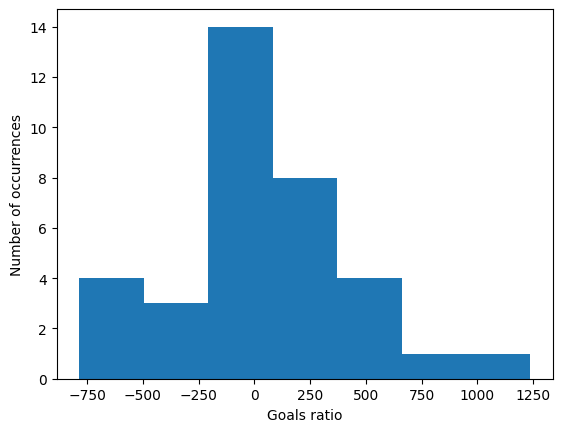

In [34]:
"""  Rice's rule is that number of bins in the histogram should 
be equal to 2*∛n, where n is number of observations in the dataset.
In our case, n=35, so ∛35 = 3.271 (cca) * 2 = 6.54, so cca 7 bins"""
plt.hist(df_goals["goals_ratio"],bins=7)
plt.ylabel("Number of occurrences")
plt.xlabel("Goals ratio")

### Histogram of the variable using the square root rule

# `victory_percentage`

Similar to the analysis of the variable `goals_ratio`, we will conduct an exploratory analysis of `victory_percentage` by following these steps:  
- Determine the basic descriptive statistics, such as the mean, median, standard deviation, minimum, and maximum.  
- Examine the distribution of the variable by using a histogram to better understand its characteristics.  
- Check if there are any obvious subgroups of teams within the variable under analysis that could be identified based on specific criteria, such as the range of the variable's values.

### Descriptive Statistics

### Distribution

Here we will create the distribution of the variable, but we won't be doing it in two versions. Instead, we will choose a different, arbitrary number of intervals.

# `goals_ratio` vs `victory_percentage`

We have already analyzed `goals_ratio` and `victory_percentage` as two separate variables. Now, our task is to analyze them together to identify potential interdependencies between them.  
  
In this step, we will perform the following exercises:  
- Before starting the analysis, let’s consider whether these variables might be dependent or independent of each other. What kind of relationship can be expected based on their business descriptions?  
- We will create a scatterplot to visually represent the dependencies between these variables.  
- We will determine the relationship between the variables based on the scatterplot.  
- We will analyze the scatterplot to identify any outliers, paying special attention to their common distribution.

## Scatterplot of Variables

Now let's create a scatterplot for the two analyzed variables, `goals_ratio` and `victory_percentage`. After completing this step, let's answer the following questions:  
- What is the relationship between the variables `goals_ratio` and `victory_percentage`?  
- Can any outliers be identified in the plot? If so, what criteria were used to identify them?

> space for chart analysis notes

If we have identified outlying observations at an earlier stage of analysis, let's now examine these specific cases. We will focus on outliers concerning the variables `goals_ratio` and `victory_percentage` to understand what features distinguish them.

The following steps should be taken for analysis:
1. Identify the specific outlying observations that were detected earlier.
2. Analyze the characteristics of these observations, paying attention to their values for the variables `goals_ratio` and `victory_percentage`.
3. Try to understand what might have caused their outlying nature. Are these instances of anomalies, or could they be the result of natural fluctuations in the data?

# Summary

In this notebook, we conducted a basic exploratory analysis of our dataset. The data was cleaned and then enriched with new variables, which we subjected to further analysis. The final step of this part is to save the processed data to a CSV file.  
  
**Let's save our data frame to the file:** `data/processed/hockey_teams.csv`, using a semicolon (`;`) as the column separator.

Next, in the following phase of our work, we will propose betting odds based on the analyzed historical data and discuss the results of this analysis.

### Writing the frame to the target location

- file name: `data/processed/hockey_teams.csv`,
- column separator: `;`,
- remember to disable index saving.